In [1]:
import jax
# jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp
from jax import config, jit, random, grad, vmap, flatten_util, hessian

from jax import random

import scipy.integrate as integrate

from thermo_oscillator_network_fns import energy_network, setup_integration, integrate_dofs

from scipy.stats import multivariate_normal

import os

import matplotlib.pyplot as plt

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


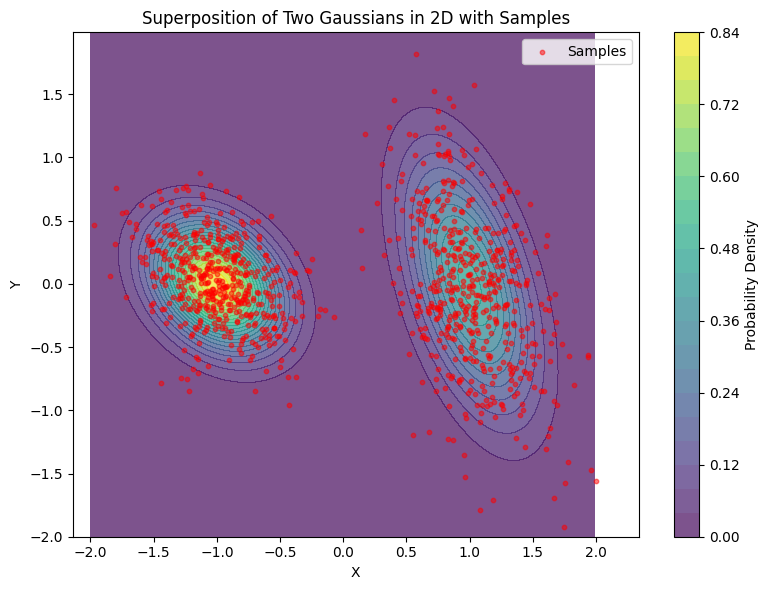

In [2]:
def sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key):
    """
    Samples from a superposition of two Gaussian distributions in 2D using JAX.
    """
    key1, key2, key3 = random.split(key, 3)
    
    # Sample from both Gaussians
    samples1 = random.multivariate_normal(key1, mu1, sigma1, shape=(n_samples,))
    samples2 = random.multivariate_normal(key2, mu2, sigma2, shape=(n_samples,))
    
    # Generate random numbers to decide which sample to keep
    choices = random.uniform(key3, shape=(n_samples,)) < p1
    
    # Select samples based on the choices
    samples = jnp.where(choices[:, None], samples1, samples2)
    
    return samples

def gaussian_pdf(x, y, mu, sigma):
    """Compute the PDF of a 2D Gaussian distribution."""
    pos = jnp.dstack((x, y))
    return multivariate_normal.pdf(pos, mean=mu, cov=sigma)

# Parameters for the first Gaussian
mu1 = jnp.array([1, 0])
sigma1 = jnp.array([[0.1, -0.1], [-0.1, 0.4]])

# Parameters for the second Gaussian
mu2 = jnp.array([-1, 0])
sigma2 = jnp.array([[0.1, -0.03], [-.03, 0.1]])

# Probability of sampling from the first Gaussian
p1 = 0.5

# Number of samples to generate
n_samples = 1000

# JAX random key
key = random.PRNGKey(0)

# Generate samples
samples = sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key)

# Create a grid for the contour plot
x_lim = 2
y_lim = 2
x, y = jnp.mgrid[-x_lim:x_lim:.01, -y_lim:y_lim:.01]

# Compute the PDF for both Gaussians
z1 = gaussian_pdf(x, y, mu1, sigma1)
z2 = gaussian_pdf(x, y, mu2, sigma2)

# Combine the PDFs according to the mixture weights
z = p1 * z1 + (1 - p1) * z2

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the contour of the combined distribution
plt.contourf(x, y, z, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(label='Probability Density')

# Plot the samples
plt.scatter(samples[:, 0], samples[:, 1], color='red', alpha=0.5, s=10, label='Samples')

plt.title('Superposition of Two Gaussians in 2D with Samples')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

In [32]:
# # Duffing params
k_lin= jnp.array([25.582, 0.394784])
k_duff = jnp.array([1., 1.0])
c_lin = jnp.array([.0])
c_optomech = jnp.array([0. ]) #12.
connectivity = jnp.array([[0, 1]])

marginalized_dofs = None #jnp.array([0,3])
non_marginalized_dofs = jnp.array([0,1])

In [41]:
integration_limits = (-0.063, 0.063)
if marginalized_dofs is not None:
    inegrator = setup_integration(marginalized_dofs, integration_limits=integration_limits, num_integration_points=10)
else:
    inegrator = setup_integration(non_marginalized_dofs, integration_limits=(-2, 2), num_integration_points=10)

In [42]:
if marginalized_dofs is not None:
    energy_network_marg = integrate_dofs(inegrator, energy_network, marginalized_dofs, non_marginalized_dofs)
else:
    energy_network_marg = energy_network

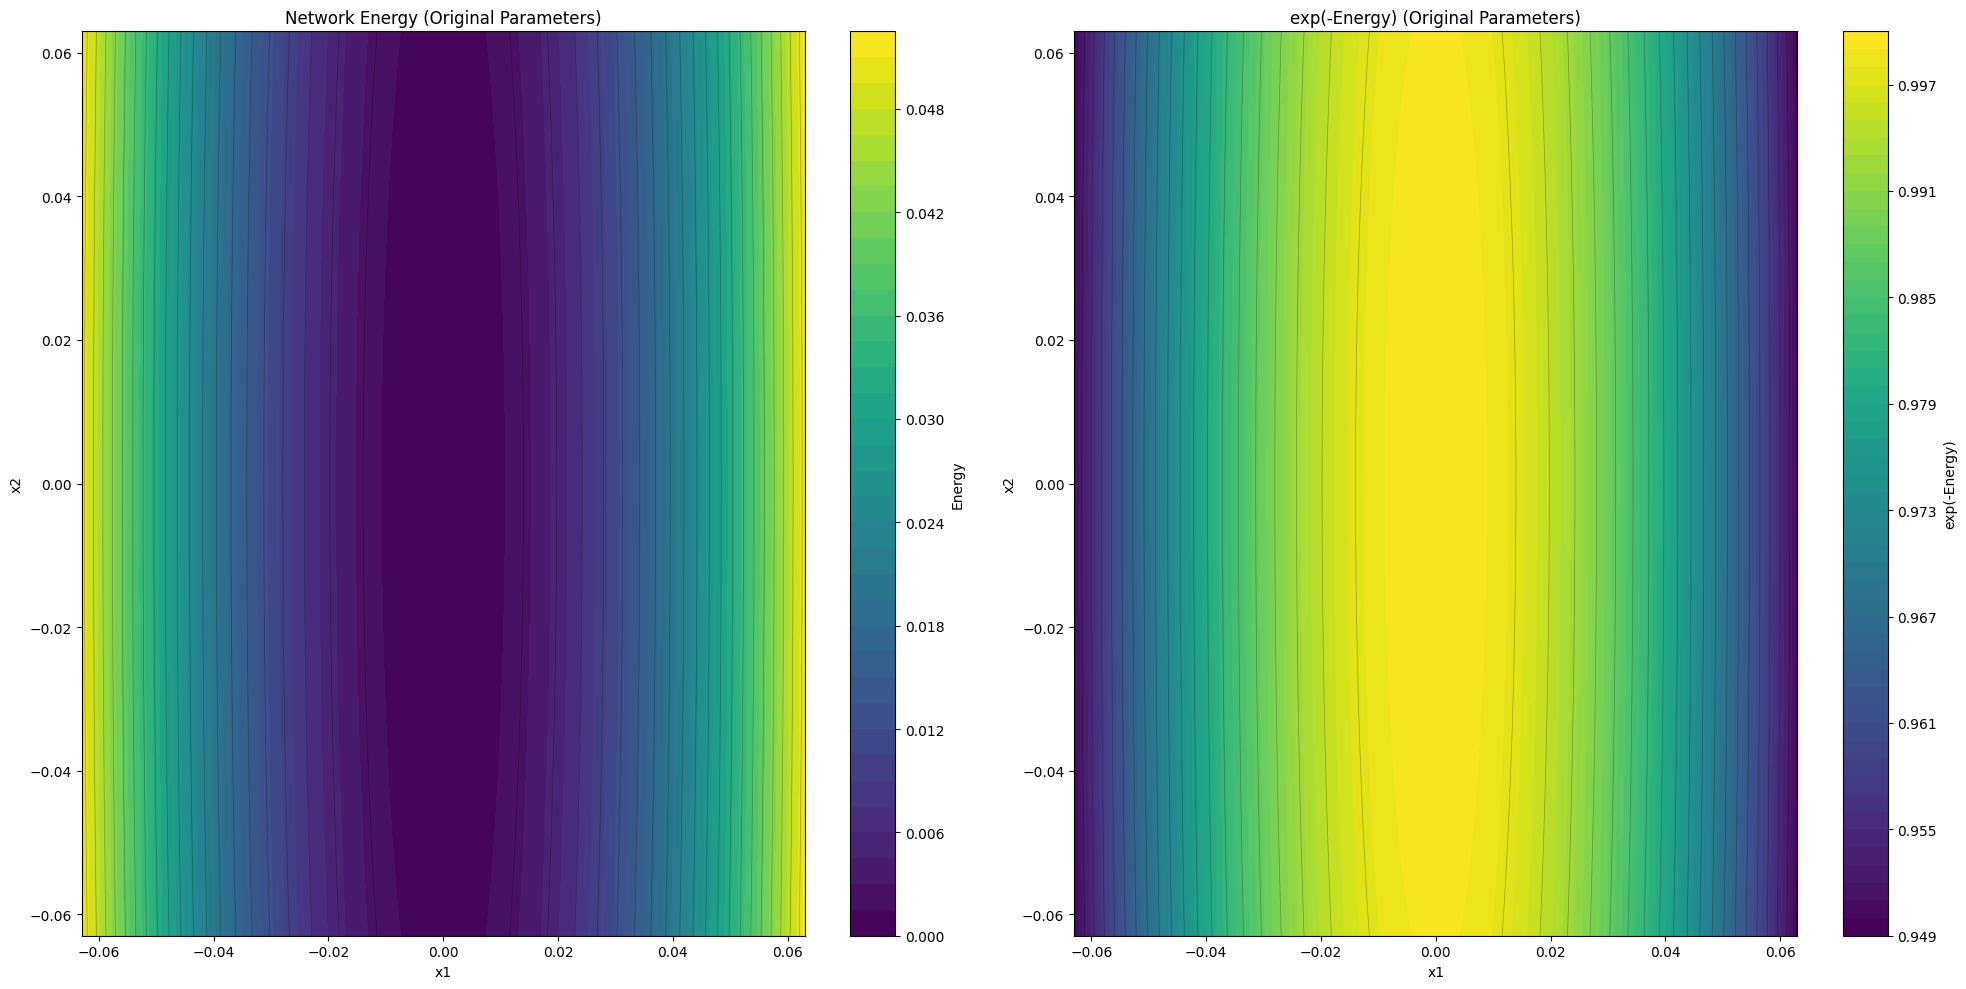

Original parameters: k_lin=[25.582     0.394784], k_duff=[1. 1.], c_lin=[0.], c_optomech=[0.]
Integration limits: (-0.063, 0.063)


In [43]:
# Define the grid for plotting using integration limits
x1_values = jnp.linspace(integration_limits[0], integration_limits[1], 100)
x2_values = jnp.linspace(integration_limits[0], integration_limits[1], 100)
X1, X2 = jnp.meshgrid(x1_values, x2_values)

# Calculate energy values for original parameters
energy_values_original = vmap(lambda x1, x2: energy_network_marg(jnp.array([x1, x2]), k_lin, k_duff, c_lin, c_optomech, connectivity))(X1.ravel(), X2.ravel())
energy_values_original = energy_values_original.reshape(X1.shape)

# Calculate exp(-energy) values
exp_neg_energy = jnp.exp(-energy_values_original)

# Create the plot with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot original energy
contour1 = ax1.contourf(X1, X2, energy_values_original, levels=50, cmap='viridis')
ax1.set_title("Network Energy (Original Parameters)")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
cbar1 = fig.colorbar(contour1, ax=ax1, label='Energy')

# Add contour lines for better visibility of energy levels
ax1.contour(X1, X2, energy_values_original, levels=20, colors='k', alpha=0.3, linewidths=0.5)

# Plot exp(-energy)
contour2 = ax2.contourf(X1, X2, exp_neg_energy, levels=50, cmap='viridis')
ax2.set_title("exp(-Energy) (Original Parameters)")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
cbar2 = fig.colorbar(contour2, ax=ax2, label='exp(-Energy)')

# Add contour lines for better visibility of exp(-energy) levels
ax2.contour(X1, X2, exp_neg_energy, levels=20, colors='k', alpha=0.3, linewidths=0.5)

plt.tight_layout()
plt.show()

# Print original parameter values for reference
print(f"Original parameters: k_lin={k_lin}, k_duff={k_duff}, c_lin={c_lin}, c_optomech={c_optomech}")
print(f"Integration limits: {integration_limits}")